In [1]:
import geopandas as gpd
import pandas as pd
import warnings
import numpy as np
from rasterstats import zonal_stats
warnings.filterwarnings('ignore')

In [2]:
data_ = gpd.read_file('/Users/mipl/Documents/Agroforestry/South India/Phase 3/Stratification/SHC Data/Input/final_master_points.geojson')
aez = gpd.read_file('/Users/mipl/Downloads/WFSServer (4)/Agro_Ecological_SubRegions.shp')
aez = aez.to_crs(data_.crs)

In [3]:
data = gpd.sjoin(data_,aez,how = 'left', predicate = 'within')

In [4]:
data = data[data['cluster'] != 0]
data['cluster'].unique()

array([2, 3, 1, 4, 5], dtype=int32)

In [5]:
data = data[['api_id', 'OC', 'STATE_UT', 'DISTRICT', 'SUB_DIST', 'geometry', 'physio_reg',  'sb_phy_reg', 'soil_type', 'climate', 'lgp','area_sqkm', 'st_area_sh',]]

In [6]:
data['cluster_unique'] = data['physio_reg'].astype(str)

In [7]:
print(list(data['SUB_DIST'].unique()))

['KOYYALAGUDEM', 'LINGAPALEM', 'NIDAMARRU', 'Peda  Araveedu', 'Darsi', 'Cumbum', 'Markapur', 'Olakkur', 'GAMPALAGUDEM', 'ATLAPRAGADA KONDURU', 'GADDAMANUGU KONDURU', 'Hirekerur', 'Ratteehalli', 'Humnabad', 'Basavakalyan', 'Pattambi', 'Ottappalam', 'Indi', 'Sindgi', 'Basavan Bagewadi', 'Tikota', 'Not under any Sub-District', 'Cuttack Sadar', 'Banki', 'Athagad', 'Banki-Dampara', 'Vinukonda', 'Veldurthi', 'ODDANCHATRAM', 'NATHAM', 'ATHOOR', 'Shanarpatti']


In [8]:
dist_counts = data.groupby(['STATE_UT','DISTRICT', 'SUB_DIST', ]).size().reset_index(name='COUNT')

# Sort by District and then by the count (highest first)
dist_counts = dist_counts.sort_values(['DISTRICT', 'COUNT'], ascending=[True, False])

In [9]:
dist_counts

,STATE_UT,DISTRICT,SUB_DIST,COUNT
14,KARNATAKA,Bidar,Basavakalyan,1471
15,KARNATAKA,Bidar,Humnabad,983
23,OD,CTT,Athagad,2805
24,OD,CTT,Banki,1493
26,OD,CTT,Cuttack Sadar,805
25,OD,CTT,Banki-Dampara,637
30,TN,DIN,Shanarpatti,563
29,TAMIL NADU,DINDIGUL,ODDANCHATRAM,1510
27,TAMIL NADU,DINDIGUL,ATHOOR,954
28,TAMIL NADU,DINDIGUL,NATHAM,766


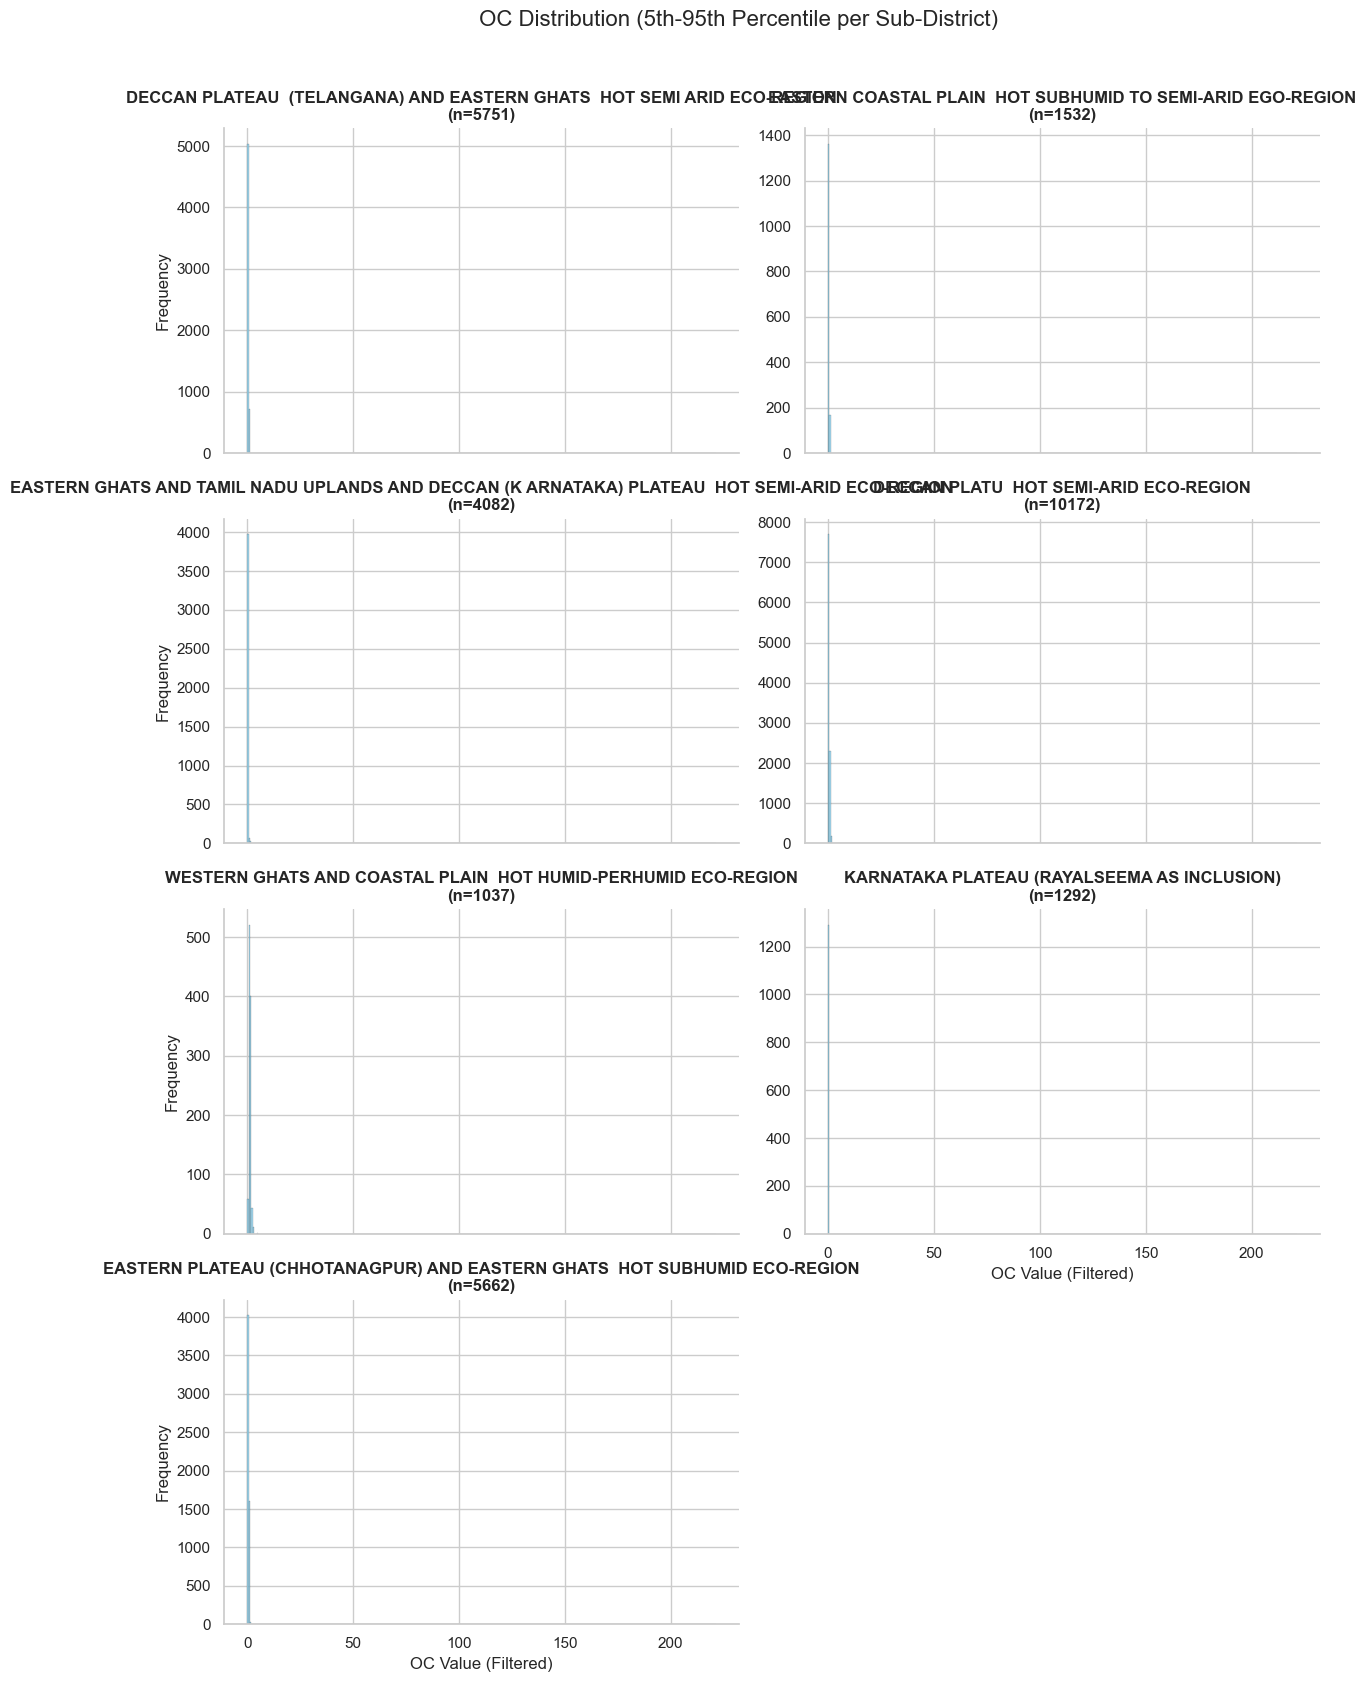

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter the data (5th to 95th percentile)
def filter_percentiles(group):
    lower = group.quantile(0.05)
    upper = group.quantile(0.95)
    return group.between(lower, upper)

data_cleaned = data[data.groupby('physio_reg')['OC'].transform(filter_percentiles)].copy()

# 2. Pre-calculate counts to ensure accuracy
counts = data['physio_reg'].value_counts().to_dict()

# 3. Set style and create plot
sns.set_theme(style="whitegrid")
g = sns.displot(
    data=data, 
    x="OC", 
    col="physio_reg", 
    col_wrap=2, 
    kind="hist", 
    height=4, 
    aspect=1.5, 
    color="skyblue", 
    edgecolor="black",
    facet_kws={'sharey': False} # Allows each plot to scale to its own N
)

# 4. Update titles by mapping the pre-calculated counts
for ax in g.axes.flat:
    # Get the title text Seaborn generated
    current_title = ax.get_title()
    
    # Strip "SUB_DIST = " if Seaborn added it automatically
    dist_name = current_title.replace("physio_reg = ", "").strip()
    
    # Retrieve count from our dictionary
    n_obs = counts.get(dist_name, 0)
    
    # Set the new title
    ax.set_title(f"{dist_name}\n(n={n_obs})", fontweight='bold', fontsize=12)

# Adjust layout
g.set_axis_labels("OC Value (Filtered)", "Frequency")
g.fig.suptitle("OC Distribution (5th-95th Percentile per Sub-District)", y=1.05, fontsize=16)

plt.show()

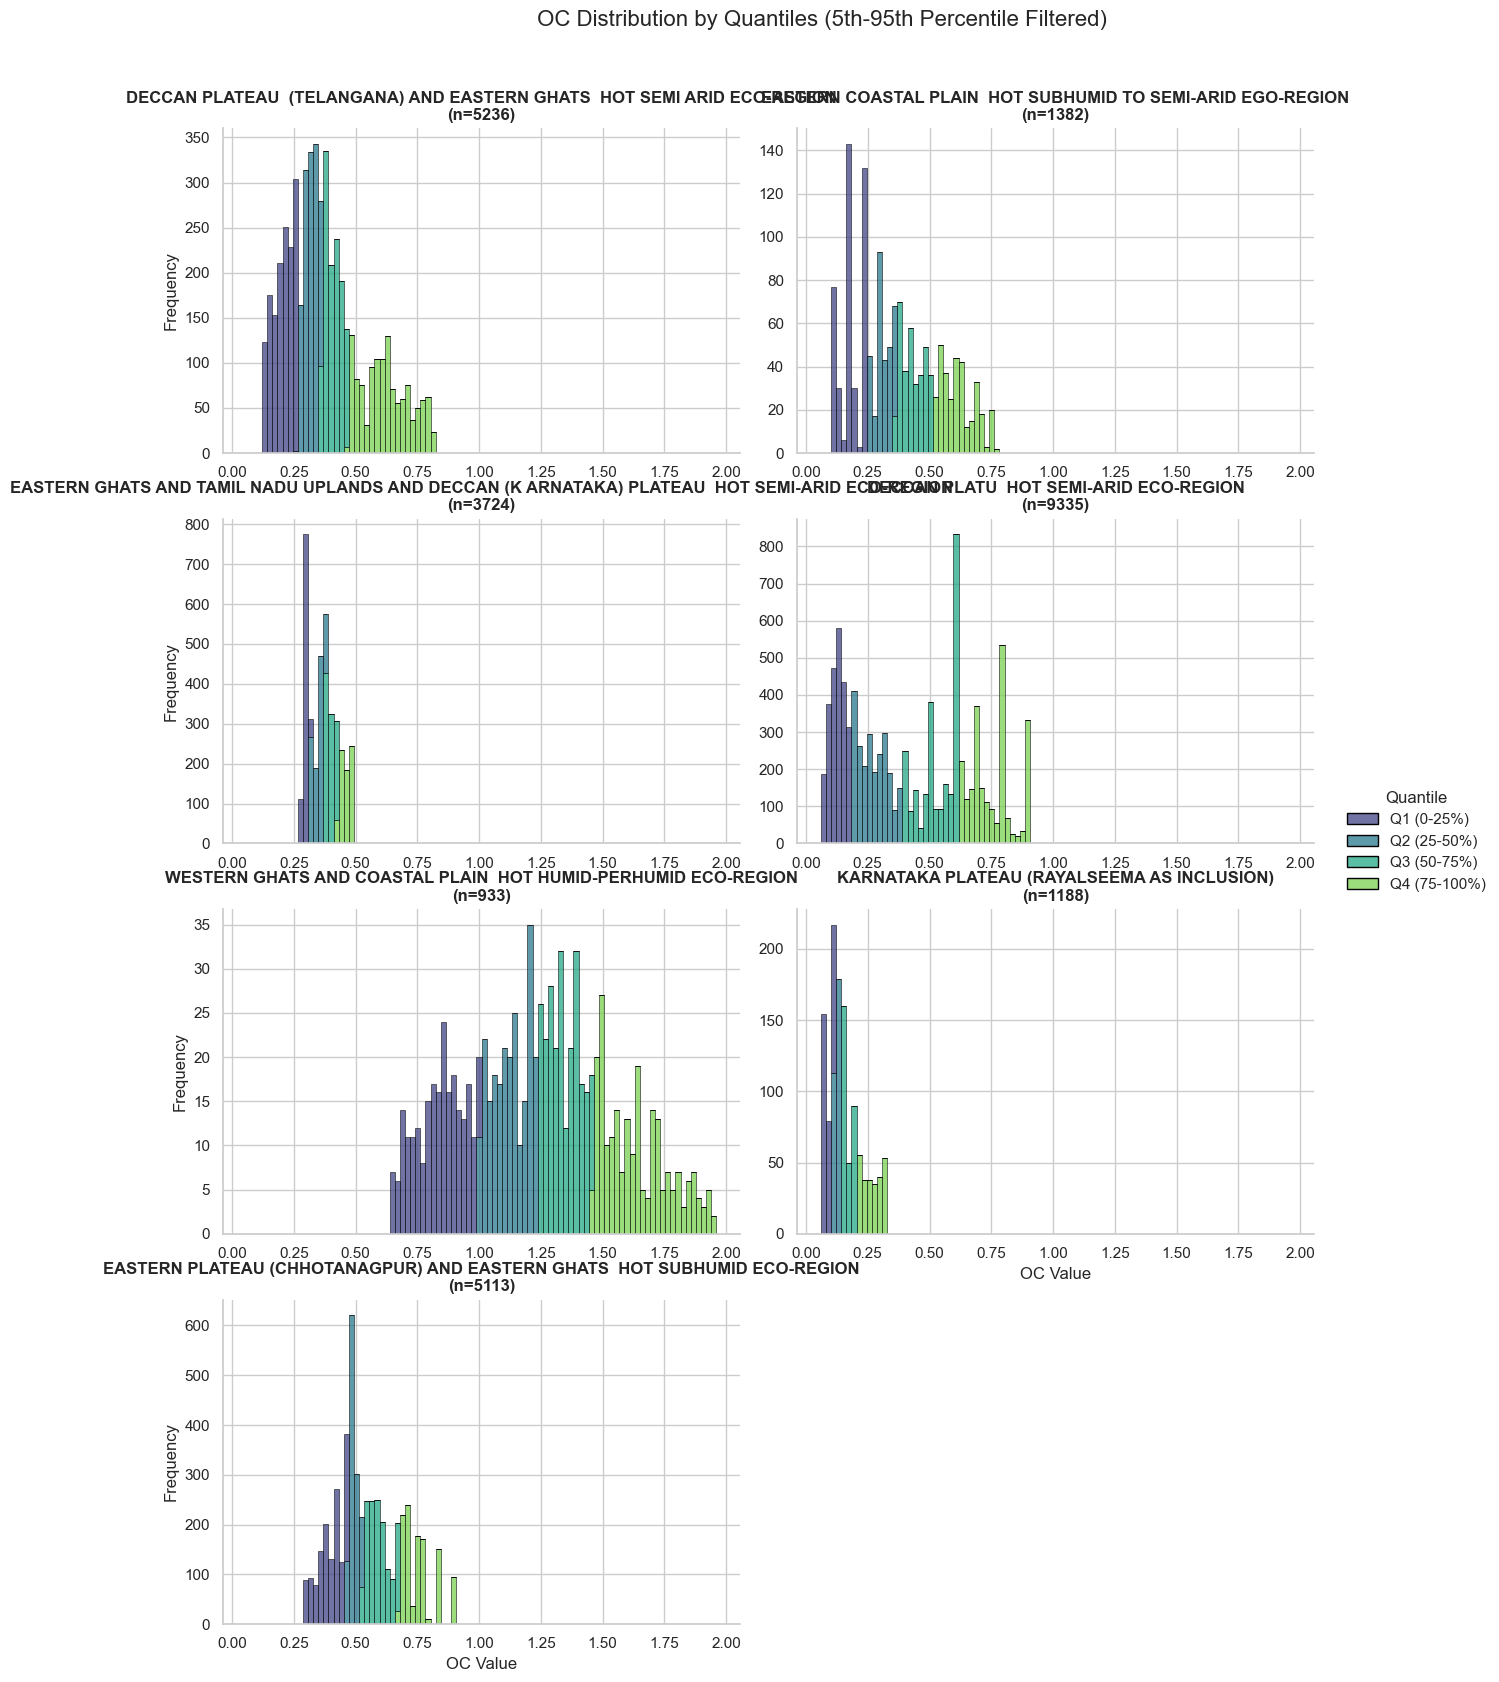

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data (5th to 95th percentile)
def filter_percentiles(group):
    lower = group.quantile(0.05)
    upper = group.quantile(0.95)
    return group.between(lower, upper)

data_cleaned = data[data.groupby('physio_reg')['OC'].transform(filter_percentiles)].copy()

# 2. Assign Quantiles per SUB_DIST
# This creates 4 buckets (Quartiles) for each sub-district independently
data_cleaned['Quantile'] = data_cleaned.groupby('physio_reg')['OC'].transform(
    lambda x: pd.qcut(x, 4, labels=["Q1 (0-25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (75-100%)"])
)

# 3. Pre-calculate counts for the titles
counts = data_cleaned['physio_reg'].value_counts().to_dict()

# 4. Set style and create plot
sns.set_theme(style="whitegrid")
g = sns.displot(
    data=data_cleaned, 
    x="OC", 
    hue="Quantile",      # This applies the different colors
    col="physio_reg", 
    col_wrap=2, 
    kind="hist", 
    multiple="stack",    # Stacks colors; use "dodge" for side-by-side or "layer"
    height=4, 
    aspect=1.5, 
    palette="viridis",   # A nice color gradient for quantiles
    edgecolor="black",
    facet_kws={'sharey': False, 'sharex': False}
)

# 5. Update titles with sample counts
for ax in g.axes.flat:
    current_title = ax.get_title()
    dist_name = current_title.replace("physio_reg = ", "").strip()
    n_obs = counts.get(dist_name, 0)
    
    if dist_name: # Ensure we don't label empty facets
        ax.set_title(f"{dist_name}\n(n={n_obs})", fontweight='bold', fontsize=12)

# Adjust labels and title
g.set_axis_labels("OC Value", "Frequency")
g.fig.suptitle("OC Distribution by Quantiles (5th-95th Percentile Filtered)", y=1.05, fontsize=16)

plt.show()

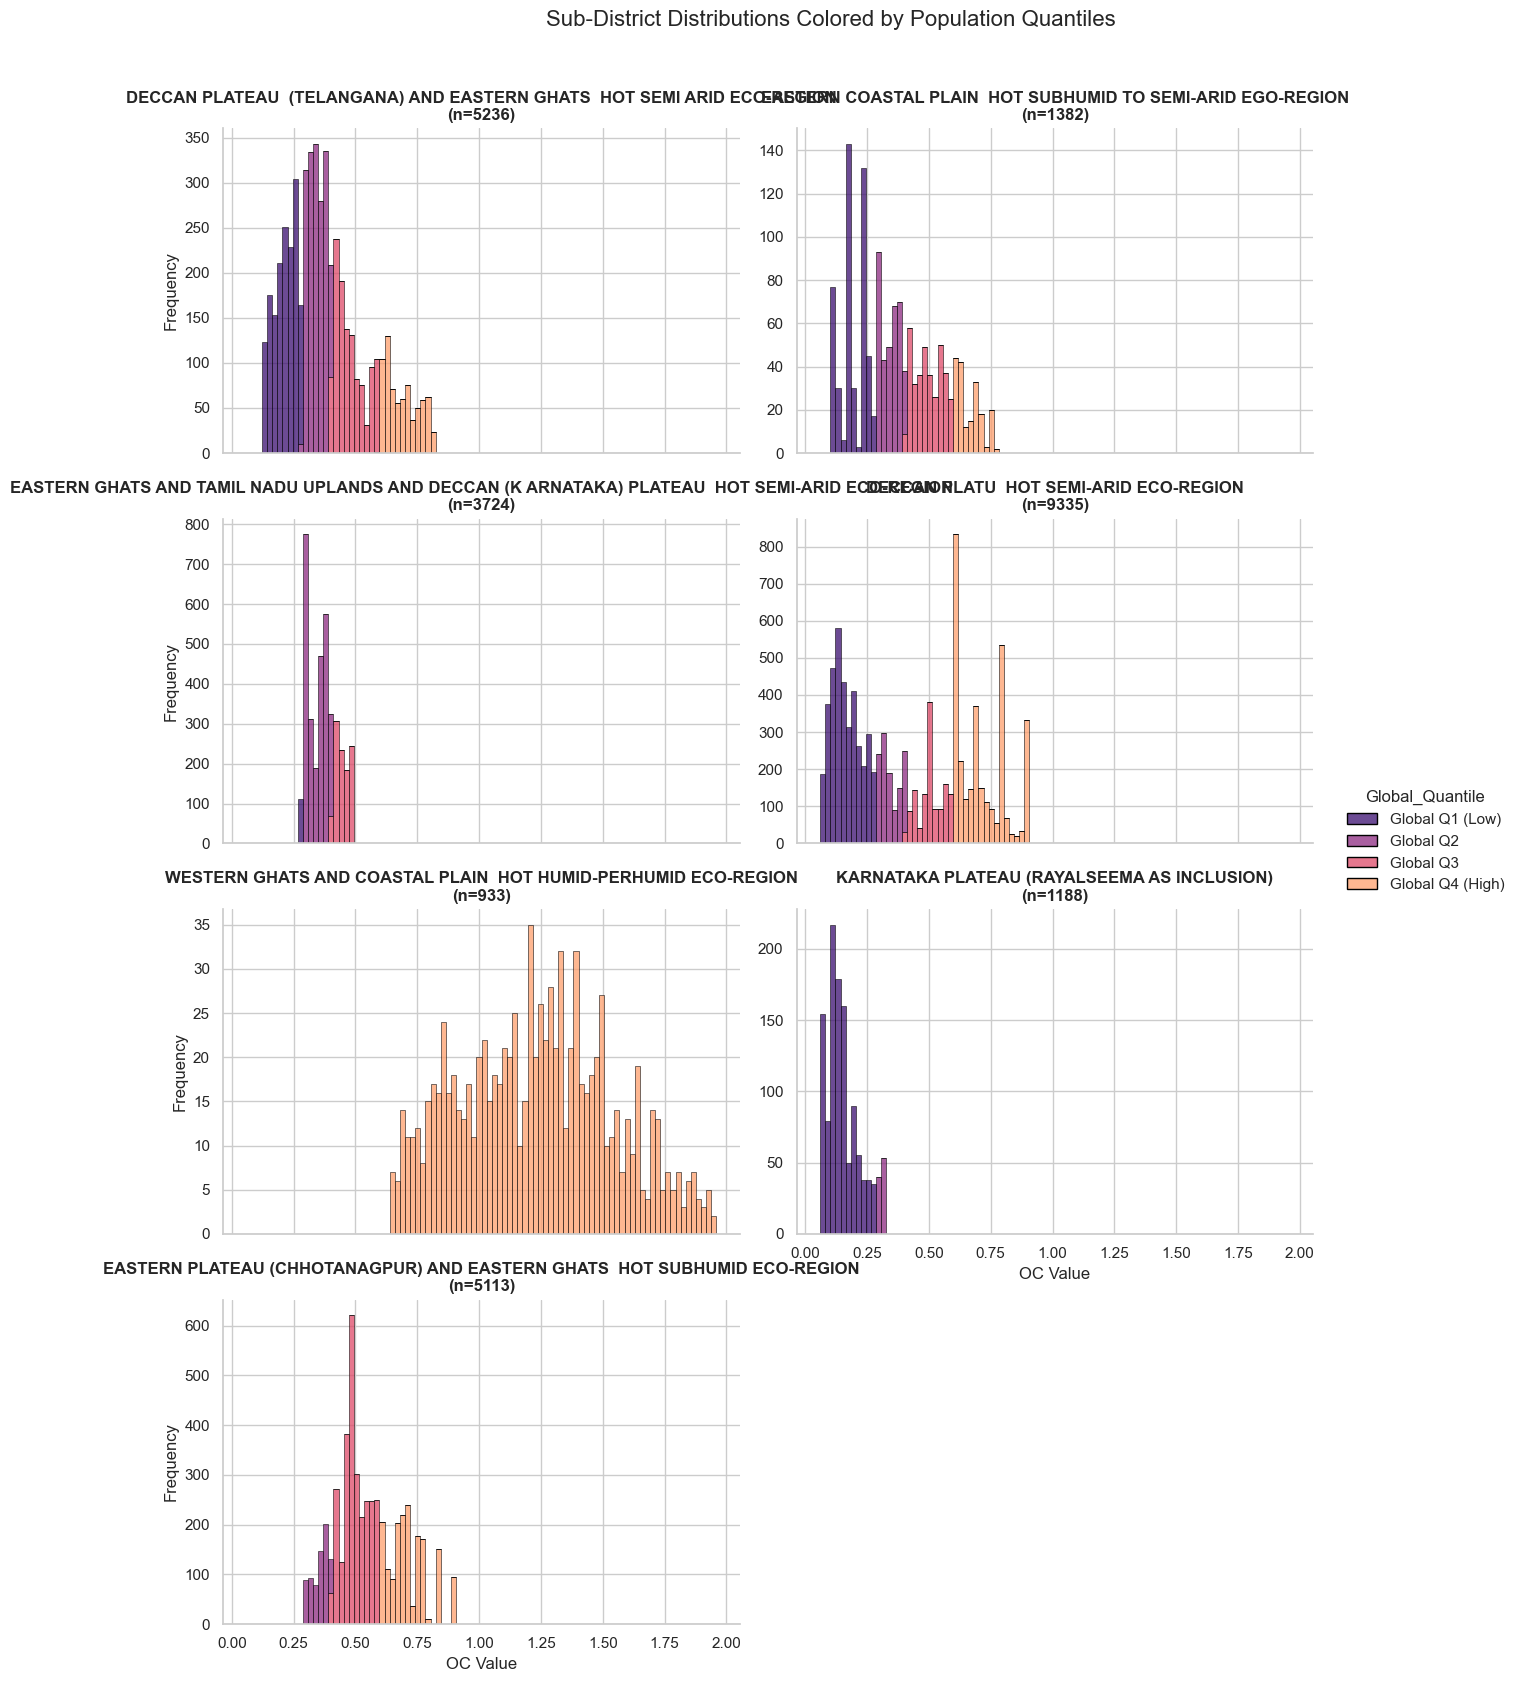

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data (5th to 95th percentile)
def filter_percentiles(group):
    lower = group.quantile(0.05)
    upper = group.quantile(0.95)
    return group.between(lower, upper)

data_cleaned = data[data.groupby('cluster_unique')['OC'].transform(filter_percentiles)].copy()

# 2. Assign Quantiles based on the WHOLE population
# We calculate qcut on the entire 'OC' column, not grouped
data_cleaned['Global_Quantile'] = pd.qcut(
    data_cleaned['OC'], 
    4, 
    labels=["Global Q1 (Low)", "Global Q2", "Global Q3", "Global Q4 (High)"]
)

# 3. Pre-calculate counts for titles
counts = data_cleaned['cluster_unique'].value_counts().to_dict()

# 4. Set style and create plot
sns.set_theme(style="whitegrid")
g = sns.displot(
    data=data_cleaned, 
    x="OC", 
    hue="Global_Quantile", 
    col="cluster_unique", 
    col_wrap=2, 
    kind="hist", 
    multiple="stack",
    height=4, 
    aspect=1.5, 
    palette="magma", # Changed palette to distinguish from previous version
    edgecolor="black",
    facet_kws={'sharey': False, 'sharex': True} # sharex=True helps compare against global scale
)

# 5. Update titles with sample counts
for ax in g.axes.flat:
    current_title = ax.get_title()
    dist_name = current_title.replace("cluster_unique = ", "").strip()
    n_obs = counts.get(dist_name, 0)
    
    if dist_name:
        ax.set_title(f"{dist_name}\n(n={n_obs})", fontweight='bold', fontsize=12)

# Adjust labels and title
g.set_axis_labels("OC Value", "Frequency")
g.fig.suptitle("Sub-District Distributions Colored by Population Quantiles", y=1.05, fontsize=16)

plt.show()

In [13]:
data[data['DISTRICT'].isin(['Niali'])]

,api_id,OC,STATE_UT,DISTRICT,SUB_DIST,geometry,physio_reg,sb_phy_reg,soil_type,climate,lgp,area_sqkm,st_area_sh,cluster_unique


In [ ]:
SOC_POOL_IN_SCOPE = True   # <-- set to True or False explicitly

# =============================================================================
# PLANNING ASSUMPTIONS  —  all analyst choices, all must be justified
# =============================================================================
Z = 1.96                 # [PLANNING ASSUMPTION] z-score. 1.96 = 95% CI.
                         #   NOTE: VM0047 uncertainty is assessed at the 90%
                         #   confidence level (z = 1.645). For a PLANNING tool
                         #   95% is conservative (asks for more cores). For any
                         #   number that feeds a compliance calc, use 1.645
                         #   and confirm against the VM0047 v1.1 PDF.

ERROR_RATE = 0.15        # [PLANNING ASSUMPTION] target margin of error as a
                         #   fraction of the stratum mean OC. Tighter = more
                         #   cores. This is a DESIGN aspiration, not a
                         #   methodology threshold.

MIN_CORES_PER_BLOCK = 2  # [PLANNING ASSUMPTION] minimum cores per sub-district
                         #   (block). Guarantees every block is spatially
                         #   represented regardless of Cochran output.
                         #   Stratum floor = n_blocks x this value.

MAX_CORES_PER_BLOCK = 3  # [PLANNING ASSUMPTION] maximum cores per sub-district
                         #   (block). Operational/budget ceiling per block.
                         #   Stratum ceiling = n_blocks x this value.
                         #   Replaces the old flat MAX_CORES_PER_STRATUM = 30:
                         #   strata covering more blocks get a proportionally
                         #   higher ceiling, and vice versa.

FIELD_LOSS_RATE = 0.20   # [PLANNING ASSUMPTION] extra cores to fund for field
                         #   losses: failed cores, access denial, lab rejects.
                         #   This is an OPERATIONAL margin. It is NOT the
                         #   VM0047 uncertainty deduction and must never be
                         #   presented as such.

PLOT_INFLUENCE_AREA_HA = 0.5   # [PLANNING ASSUMPTION] hectares represented by
                               #   one potential core, used to derive a finite
                               #   population size N per stratum. 0.5 is a
                               #   placeholder -- justify from plot design.

# Strata with too few points have an unreliable std. Decide how to treat them.
# 'pooled'      -> assign the project-wide pooled std (recommended, neutral)
# 'max'         -> assign the largest observed stratum std (conservative)
# 'flag_only'   -> keep them but flag; do not trust their computed n
MIN_POINTS_FOR_RELIABLE_STD = 10      # [PLANNING ASSUMPTION]
LOW_DATA_STD_STRATEGY = 'pooled'      # [PLANNING ASSUMPTION]


# =============================================================================
# CORE CALCULATION
# =============================================================================
def cochran_n(std, mean, N, z=Z, error_rate=ERROR_RATE):
    """
    Cochran sample size with finite population correction.

        n = (z^2 * s^2) / (e^2 + (z^2 * s^2 / N))    where e = error_rate * mean

    Returns np.nan if the stratum mean is non-positive (formula undefined).
    This is standard survey statistics -- it is NOT a VM0047 procedure.
    """
    if mean is None or mean <= 0 or std is None or np.isnan(std):
        return np.nan
    e_abs = error_rate * mean
    if e_abs <= 0:
        return np.nan
    z_sq = z ** 2
    s_sq = std ** 2
    num = z_sq * s_sq
    den = (e_abs ** 2) + (num / N)
    return float(np.ceil(num / den))


def plan_sample_sizes(stats):
    """
    Input: a DataFrame with one row per stratum and columns:
        cluster_unique, OC_std_dev, OC_count, OC_mean, total_area, n_blocks
    Output: the same DataFrame with planning columns added. Nothing is hidden;
    every intermediate number is kept so choices can be inspected and defended.

    Block-proportional limits: the floor and ceiling for planned cores scale
    with the number of sub-districts (blocks) in each stratum:
        floor   = n_blocks x MIN_CORES_PER_BLOCK
        ceiling = n_blocks x MAX_CORES_PER_BLOCK
    This ensures strata with more blocks (greater spatial footprint) receive
    more cores, and strata with fewer blocks are not over-sampled.
    """
    df = stats.copy()

    # --- Data-quality guards: do NOT silently fillna(0) ---------------------
    df['n_points'] = df['OC_count'].fillna(0).astype(int)
    df['flag_single_point'] = df['n_points'] < 2
    df['flag_low_data']     = df['n_points'] < MIN_POINTS_FOR_RELIABLE_STD
    df['flag_nonpos_mean']  = df['OC_mean'].fillna(0) <= 0

    # --- Repair unreliable / missing std explicitly -------------------------
    reliable = df.loc[~df['flag_low_data'], 'OC_std_dev'].dropna()
    pooled_std = reliable.mean() if len(reliable) else df['OC_std_dev'].dropna().mean()
    max_std    = df['OC_std_dev'].dropna().max()

    def resolve_std(row):
        s = row['OC_std_dev']
        if pd.notna(s) and not row['flag_low_data']:
            return s, 'observed'
        if LOW_DATA_STD_STRATEGY == 'pooled':
            return pooled_std, 'imputed_pooled'
        if LOW_DATA_STD_STRATEGY == 'max':
            return max_std, 'imputed_max'
        return s, 'unreliable_kept'   # 'flag_only'

    resolved = df.apply(resolve_std, axis=1, result_type='expand')
    df['std_used'] = resolved[0]
    df['std_source'] = resolved[1]

    # --- Finite population size N from area ---------------------------------
    df['N_population'] = np.maximum(
        df['total_area'].fillna(0) / PLOT_INFLUENCE_AREA_HA,
        1,
    )

    # --- Raw Cochran n ------------------------------------------------------
    df['n_cochran_raw'] = df.apply(
        lambda r: cochran_n(r['std_used'], r['OC_mean'], r['N_population']),
        axis=1,
    )

    # --- Operational field-loss buffer (applied BEFORE the cap) -------------
    df['n_with_field_buffer'] = np.ceil(
        df['n_cochran_raw'] * (1 + FIELD_LOSS_RATE)
    )

    # --- Block-proportional floor and ceiling ------------------------------
    # A flat cap of 30 treated a 21-block stratum the same as a 4-block one.
    # Scaling by n_blocks corrects that: more blocks -> higher ceiling.
    n_blk = df['n_blocks'].fillna(1).astype(int)
    df['block_floor']   = n_blk * MIN_CORES_PER_BLOCK
    df['block_ceiling'] = n_blk * MAX_CORES_PER_BLOCK

    def finalize(row):
        n       = row['n_with_field_buffer']
        floor   = int(row['block_floor'])
        ceiling = int(row['block_ceiling'])
        if pd.isna(n):
            return floor   # no Cochran result -> fall back to block floor
        return int(max(floor, min(n, ceiling)))

    df['planned_cores'] = df.apply(finalize, axis=1)

    # --- Transparency flags -------------------------------------------------
    df['flag_capped'] = (
        df['n_with_field_buffer'].fillna(0) > df['block_ceiling']
    )
    df['flag_used_floor_fallback'] = (
        df['n_with_field_buffer'].isna() |
        (df['n_with_field_buffer'] < df['block_floor'])
    )

    return df


# =============================================================================
# EXECUTION
# =============================================================================
if SOC_POOL_IN_SCOPE is None:
    raise SystemExit(
        "STOP: set SOC_POOL_IN_SCOPE to True or False first.\n"
        "Under VM0047 the soil pool is OPTIONAL unless project soil "
        "disturbance is repeated or exceeds 25 cm inversion depth. "
        "If SOC is excluded you do not need to budget soil cores."
    )
if SOC_POOL_IN_SCOPE is False:
    raise SystemExit(
        "SOC_POOL_IN_SCOPE is False: SOC is excluded from your project "
        "boundary, so no soil-core budget is required. Nothing to plan."
    )

# --- Build per-stratum OC stats --------------------------------------------
stats = (
    data_cleaned
    .groupby('cluster_unique')['OC']
    .agg(OC_std_dev='std', OC_count='count', OC_mean='mean')
    .reset_index()
)

# --- Area per stratum -------------------------------------------------------
zone = pd.read_csv('aez_distribution.csv')
stats = pd.merge(stats, zone, on='cluster_unique', how='left')

# --- Block (sub-district) count per stratum ---------------------------------
# The floor and ceiling for each stratum scale with how many operational
# sub-districts (blocks) fall within it.
blocks_raw = pd.read_csv('block_aez_distribution.csv')
zone_area_cols = [c for c in blocks_raw.columns if c.startswith('Area_')]
block_counts_df = pd.DataFrame({
    'cluster_unique': [c.replace('Area_', '') for c in zone_area_cols],
    'n_blocks':       [(blocks_raw[c] > 0).sum() for c in zone_area_cols],
})
stats = pd.merge(stats, block_counts_df, on='cluster_unique', how='left')
stats['n_blocks'] = stats['n_blocks'].fillna(1).astype(int)

plan = plan_sample_sizes(stats)

cols = ['cluster_unique', 'n_points', 'n_blocks', 'OC_mean', 'OC_std_dev',
        'std_used', 'std_source', 'N_population',
        'n_cochran_raw', 'n_with_field_buffer',
        'block_floor', 'block_ceiling', 'planned_cores',
        'flag_single_point', 'flag_low_data', 'flag_nonpos_mean',
        'flag_capped', 'flag_used_floor_fallback']
plan = plan[[c for c in cols if c in plan.columns]]

print(plan.to_string(index=False))
print(f"\nTOTAL CORES TO BUDGET: {int(plan['planned_cores'].sum())}")

capped = plan.loc[plan['flag_capped'], 'cluster_unique'].tolist()
if capped:
    print(f"\n[!] {len(capped)} strata hit their block ceiling "
          f"({MAX_CORES_PER_BLOCK} cores/block x n_blocks) -- "
          f"statistically wanted more cores: {capped}")

floored = plan.loc[plan['flag_used_floor_fallback'], 'cluster_unique'].tolist()
if floored:
    print(f"[!] {len(floored)} strata raised to block floor "
          f"({MIN_CORES_PER_BLOCK} cores/block x n_blocks): {floored}")

low = plan.loc[plan['flag_low_data'], 'cluster_unique'].tolist()
if low:
    print(f"[!] {len(low)} strata have <{MIN_POINTS_FOR_RELIABLE_STD} pilot "
          f"points; their std was imputed ('{LOW_DATA_STD_STRATEGY}'). "
          f"Treat their core counts as weak estimates: {low}")

In [15]:
plan['n_with_field_buffer'].sum()

np.float64(225.0)

In [ ]:
plan.to_csv('min_samples_may_21st_2026.csv')

In [16]:
plan

,cluster_unique,n_points,OC_mean,OC_std_dev,std_used,std_source,N_population,n_cochran_raw,n_with_field_buffer,planned_cores,flag_single_point,flag_low_data,flag_nonpos_mean,flag_capped,flag_used_floor_fallback
0,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,5236,0.379932,0.164057,0.164057,observed,17353.772456,32.0,39.0,30,False,False,False,True,False
1,DECCAN PLATU HOT SEMI-ARID ECO-REGION,9335,0.418165,0.247855,0.247855,observed,11811.860938,60.0,72.0,30,False,False,False,True,False
2,EASTERN COASTAL PLAIN HOT SUBHUMID TO SEMI-AR...,1382,0.372685,0.170379,0.170379,observed,1104.338831,35.0,42.0,30,False,False,False,True,False
3,EASTERN GHATS AND TAMIL NADU UPLANDS AND DECCA...,3724,0.369418,0.061379,0.061379,observed,4386.727956,5.0,6.0,13,False,False,False,False,False
4,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,5113,0.552271,0.139177,0.139177,observed,2824.926793,11.0,14.0,14,False,False,False,False,False
5,KARNATAKA PLATEAU (RAYALSEEMA AS INCLUSION),1188,0.158030,0.067333,0.067333,observed,2936.184508,31.0,38.0,30,False,False,False,True,False
6,WESTERN GHATS AND COASTAL PLAIN HOT HUMID-PER...,933,1.230262,0.308361,0.308361,observed,1029.758245,11.0,14.0,14,False,False,False,False,False
